In [1]:
import os
import shutil
import random
import numpy as np
import pandas as pd
import cv2
from tqdm import tqdm

import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras import layers, models, optimizers

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    precision_recall_fscore_support, roc_curve
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [2]:
ROOT_FOLDER = '/kaggle/input/datasets/ruii2401/isic-2019'

# Đường dẫn file nhãn (Ground Truth)
TRAIN_CSV = os.path.join(ROOT_FOLDER, 'ISIC_2019_Training_GroundTruth.csv')
TEST_CSV = os.path.join(ROOT_FOLDER, 'ISIC_2019_Test_GroundTruth.csv')

train_img_folder = os.path.join(ROOT_FOLDER, 'ISIC_2019_Training_Input', 'ISIC_2019_Training_Input')
test_img_folder = os.path.join(ROOT_FOLDER, 'ISIC_2019_Test_Input', 'ISIC_2019_Test_Input')

WORKING_DIR = ROOT_FOLDER
PROCESSED_DIR = '/kaggle/working/processed_images/'
os.makedirs(PROCESSED_DIR, exist_ok=True)

# EDA

In [3]:
# --- LOAD, CHƯA GIẢ ĐỊNH GÌ VỀ CỘT ---
df_train_gt = pd.read_csv(TRAIN_CSV)

print("=== CỘT TRONG GROUND TRUTH ===")
print(df_train_gt.columns.tolist())
print(f"\nShape: {df_train_gt.shape}")
print(df_train_gt.head())

=== CỘT TRONG GROUND TRUTH ===
['image', 'MEL', 'NV', 'BCC', 'AK', 'BKL', 'DF', 'VASC', 'SCC', 'UNK']

Shape: (25331, 10)
          image  MEL   NV  BCC   AK  BKL   DF  VASC  SCC  UNK
0  ISIC_0000000  0.0  1.0  0.0  0.0  0.0  0.0   0.0  0.0  0.0
1  ISIC_0000001  0.0  1.0  0.0  0.0  0.0  0.0   0.0  0.0  0.0
2  ISIC_0000002  1.0  0.0  0.0  0.0  0.0  0.0   0.0  0.0  0.0
3  ISIC_0000003  0.0  1.0  0.0  0.0  0.0  0.0   0.0  0.0  0.0
4  ISIC_0000004  1.0  0.0  0.0  0.0  0.0  0.0   0.0  0.0  0.0


Có tổng cộng 25331 tấm ảnh và 9 mẫu bệnh, trong đó có 8 bệnh đã xác định và 1 lớp UNK - Unknows

In [4]:
# Các cột không phải 'image' chính là các nhóm bệnh (nhãn one-hot)
disease_cols = [c for c in df_train_gt.columns if c != 'image']
print(f"Số nhóm bệnh: {len(disease_cols)}")
print(disease_cols)

print("\n=== SỐ LƯỢNG ẢNH THEO TỪNG NHÓM ===")
counts = df_train_gt[disease_cols].sum().sort_values(ascending=False)
print(counts)

Số nhóm bệnh: 9
['MEL', 'NV', 'BCC', 'AK', 'BKL', 'DF', 'VASC', 'SCC', 'UNK']

=== SỐ LƯỢNG ẢNH THEO TỪNG NHÓM ===
NV      12875.0
MEL      4522.0
BCC      3323.0
BKL      2624.0
AK        867.0
SCC       628.0
VASC      253.0
DF        239.0
UNK         0.0
dtype: float64


Nhận xét: phân bố không đều. Lớp NV chiếm gần 1 nửa so với các lớp bệnh còn lại, trong khi đó lớp UNK không hề có trong train test -> thách thức

In [5]:
df_test_gt = pd.read_csv(TEST_CSV)

print("=== CỘT TRONG TEST GROUND TRUTH ===")
print(df_test_gt.columns.tolist())
print(f"\nShape: {df_test_gt.shape}")
print(df_test_gt.head())



=== CỘT TRONG TEST GROUND TRUTH ===
['image', 'MEL', 'NV', 'BCC', 'AK', 'BKL', 'DF', 'VASC', 'SCC', 'UNK', 'score_weight', 'validation_weight']

Shape: (8238, 12)
          image  MEL   NV  BCC   AK  BKL   DF  VASC  SCC  UNK  score_weight  \
0  ISIC_0034321  0.0  1.0  0.0  0.0  0.0  0.0   0.0  0.0  0.0           0.0   
1  ISIC_0034322  0.0  1.0  0.0  0.0  0.0  0.0   0.0  0.0  0.0           0.0   
2  ISIC_0034323  0.0  0.0  1.0  0.0  0.0  0.0   0.0  0.0  0.0           0.0   
3  ISIC_0034324  0.0  1.0  0.0  0.0  0.0  0.0   0.0  0.0  0.0           0.0   
4  ISIC_0034325  0.0  1.0  0.0  0.0  0.0  0.0   0.0  0.0  0.0           0.0   

   validation_weight  
0                1.0  
1                1.0  
2                1.0  
3                1.0  
4                1.0  


In [6]:
# Các cột không phải 'image', 'score_weight', 'validation_weight' là các nhóm bệnh
disease_cols_test = [c for c in df_test_gt.columns if c not in ['image', 'score_weight', 'validation_weight']]
print(f"Số nhóm bệnh (TEST): {len(disease_cols_test)}")
print(disease_cols_test)

print("\n=== SỐ LƯỢNG ẢNH THEO TỪNG NHÓM (TEST) ===")
counts_test = df_test_gt[disease_cols_test].sum().sort_values(ascending=False)
print(counts_test)

Số nhóm bệnh (TEST): 9
['MEL', 'NV', 'BCC', 'AK', 'BKL', 'DF', 'VASC', 'SCC', 'UNK']

=== SỐ LƯỢNG ẢNH THEO TỪNG NHÓM (TEST) ===
NV      2495.0
UNK     2047.0
MEL     1327.0
BCC      975.0
BKL      660.0
AK       374.0
SCC      165.0
VASC     104.0
DF        91.0
dtype: float64


- khác với tập train, tập test lại có tận 2047 ảnh -> thách thức cho việc huấn luyện do tập train không hề có 1 ảnh nào nhãn UNK, nên có thể sẽ làm 1 ngưỡng Threshold để lọc

- Không dùng score_weight/validation_weight vì đây là cờ phục vụ chấm điểm leaderboard chính thức ISIC (9-class, không public), không áp dụng cho bài toán closed-set 8 lớp của project này

In [7]:
disease_cols_test = [c for c in df_test_gt.columns if c not in ['image', 'score_weight', 'validation_weight']]

# Tiền Xử Lý Ảnh

In [8]:
def dull_razor_and_enhance(image_path, blackhat_thresh=10, inpaint_radius=3, max_mask_ratio=0.15):
    img = cv2.imread(image_path)
    if img is None:
        return None, None
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (17, 17))
    blackhat = cv2.morphologyEx(gray, cv2.MORPH_BLACKHAT, kernel)
    _, mask = cv2.threshold(blackhat, blackhat_thresh, 255, cv2.THRESH_BINARY)

    # --- SANITY CHECK: nếu mask chiếm quá nhiều diện tích ảnh, khả năng cao
    # đang xóa nhầm vùng tổn thương chứ không chỉ lông ---
    mask_ratio = (mask > 0).sum() / mask.size
    if mask_ratio > max_mask_ratio:
        # Bỏ qua bước xóa lông cho ảnh này, chỉ giữ nguyên (an toàn hơn là phá ảnh)
        img_clean = img_rgb.copy()
    else:
        img_clean = cv2.inpaint(img_rgb, mask, inpaint_radius, cv2.INPAINT_TELEA)

    img_smooth = cv2.medianBlur(img_clean, 3)

    lab = cv2.cvtColor(img_smooth, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    l_enhanced = clahe.apply(l)
    img_final = cv2.cvtColor(cv2.merge((l_enhanced, a, b)), cv2.COLOR_LAB2RGB)

    return img_rgb, img_final

In [9]:
classes = ['MEL', 'NV', 'BCC', 'AK', 'BKL', 'DF', 'VASC', 'SCC']

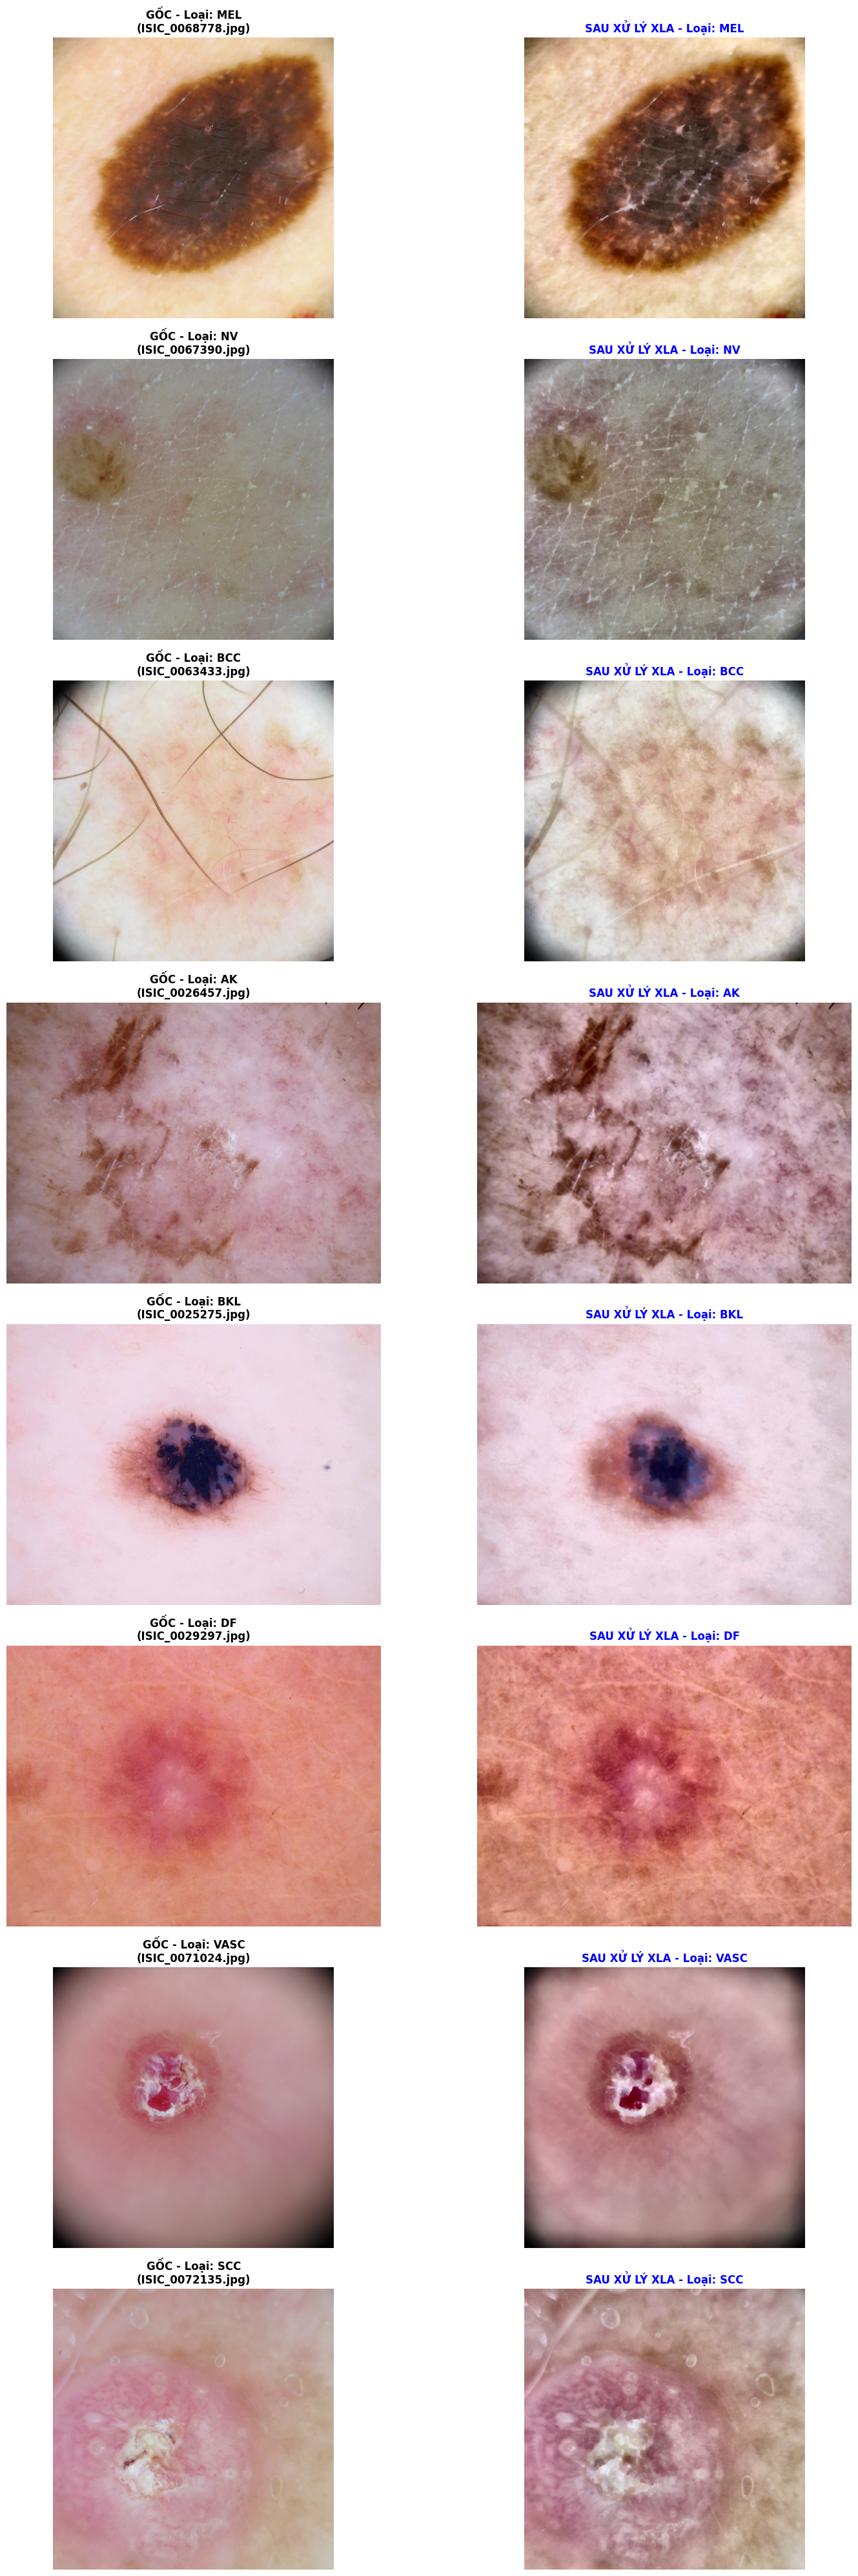

In [10]:
df_train = pd.read_csv(TRAIN_CSV)

def get_8_samples_by_class(df):
    sample_list = []
    for cls in classes:
        # Lọc các ảnh thuộc lớp này
        subset = df[df[cls] == 1.0]
        if not subset.empty:
            # Chọn ngẫu nhiên 1 ảnh
            img_id = subset.sample(1)['image'].values[0]
            # Đảm bảo có đuôi .jpg
            file_name = f"{img_id}.jpg" if not str(img_id).endswith('.jpg') else img_id
            sample_list.append((file_name, cls))
    return sample_list

# 3. THỰC HIỆN LẤY MẪU
samples = get_8_samples_by_class(df_train)

# 4. HIỂN THỊ KẾT QUẢ SO SÁNH (8 hàng x 2 cột)
plt.figure(figsize=(16, 40))

for i, (file_name, cls_name) in enumerate(samples):
    # Đường dẫn ảnh gốc trong folder đã giải nén
    path = os.path.join(train_img_folder, file_name)

    # Thực hiện tiền xử lý XLA
    orig, proc = dull_razor_and_enhance(path)

    if orig is not None:
        # Cột bên trái: Ảnh gốc
        plt.subplot(8, 2, 2*i + 1)
        plt.imshow(orig)
        plt.title(f"GỐC - Loại: {cls_name}\n({file_name})", fontsize=12, fontweight='bold')
        plt.axis('off')

        # Cột bên phải: Ảnh sau xử lý
        plt.subplot(8, 2, 2*i + 2)
        plt.imshow(proc)
        plt.title(f"SAU XỬ LÝ XLA - Loại: {cls_name}", fontsize=12, color='blue', fontweight='bold')
        plt.axis('off')
    else:
        print(f"⚠️ Không tìm thấy file: {path}")

plt.tight_layout()
plt.show()

In [11]:
df_full = pd.read_csv(TRAIN_CSV)
df_full = df_full[df_full['UNK'] != 1.0]
df_sample = df_full.copy()   # dùng toàn bộ, không sample nữa
df_sample['image_file'] = df_sample['image'].apply(lambda x: f"{x}.jpg")

TOTAL_COUNT = len(df_sample)
print(f"📊 Tổng số ảnh sẽ xử lý: {TOTAL_COUNT}")

# 3. LÀM SẠCH THƯ MỤC ĐẦU RA (Xóa cũ tạo mới)
if os.path.exists(PROCESSED_DIR):
    shutil.rmtree(PROCESSED_DIR)
os.makedirs(PROCESSED_DIR, exist_ok=True)

# 4. VÒNG LẶP XỬ LÝ XLA (DIP)
print(f"🚀 Bắt đầu xử lý XLA cho {TOTAL_COUNT} ảnh...")

for _, row in tqdm(df_sample.iterrows(), total=len(df_sample)):
    img_name = row['image_file']
    input_path = os.path.join(train_img_folder, img_name)
    output_path = os.path.join(PROCESSED_DIR, img_name)

    if os.path.exists(input_path):
        _, processed_img = dull_razor_and_enhance(input_path)
        if processed_img is not None:
            processed_img_resized = cv2.resize(processed_img, (224, 224))
            cv2.imwrite(output_path, cv2.cvtColor(processed_img_resized, cv2.COLOR_RGB2BGR))

print(f"\n✅ Xử lý xong! {len(os.listdir(PROCESSED_DIR))} ảnh sạch đã sẵn sàng tại: {PROCESSED_DIR}")

📊 Tổng số ảnh sẽ xử lý: 25331
🚀 Bắt đầu xử lý XLA cho 25331 ảnh...


100%|██████████| 25331/25331 [40:52<00:00, 10.33it/s]


✅ Xử lý xong! 25331 ảnh sạch đã sẵn sàng tại: /kaggle/working/processed_images/


In [12]:
import tensorflow as tf
from tensorflow.keras.layers import Layer, Conv2D, Dense, Dropout

# 1. ĐỊNH NGHĨA LỚP SOFT ATTENTION (Đã tích hợp Global Sum Pooling)
class SoftAttention(Layer):
    def __init__(self, **kwargs):
        super(SoftAttention, self).__init__(**kwargs)

    def build(self, input_shape):
        # input_shape: (batch, h, w, ch)
        # Conv 1x1 để tính điểm năng lượng e_ij
        self.energy_conv = Conv2D(
            filters=1,
            kernel_size=(1, 1),
            padding='same',
            activation='linear',
            name='energy_score'
        )
        super(SoftAttention, self).build(input_shape)

    def call(self, x):
        # Bước 1: Tính năng lượng e_ij
        e = self.energy_conv(x)  # (batch, h, w, 1)

        # Bước 2: Chuẩn hóa Softmax trên toàn bộ không gian (H*W)
        orig_shape = tf.shape(e)
        b, h, w, c = orig_shape[0], orig_shape[1], orig_shape[2], orig_shape[3]

        flat = tf.reshape(e, (b, h * w, c))
        softmax_flat = tf.nn.softmax(flat, axis=1)
        alpha = tf.reshape(softmax_flat, (b, h, w, c))  # (batch, h, w, 1)

        # Bước 3: Nhân trọng số attention vào feature map gốc
        F_att = x * alpha  # (batch, h, w, ch)

        # Bước 4: Tích hợp Global Sum Pooling tạo ra Vector ngữ cảnh
        # Tính tổng theo chiều không gian (axis 1 và 2 tương ứng với h và w)
        context_vector = tf.reduce_sum(F_att, axis=[1, 2])
        
        return context_vector # Kết quả là vector 1D (batch, ch)

    def compute_output_shape(self, input_shape):
        return (input_shape[0], input_shape[-1])

    def get_config(self):
        return super(SoftAttention, self).get_config()

In [13]:
def build_hybrid_model(num_classes=8):
    base_model = tf.keras.applications.MobileNetV2(
        input_shape=(224, 224, 3),
        include_top=False,
        weights='imagenet'
    )

    # Giai đoạn 1: đóng băng toàn bộ mạng nền
    base_model.trainable = False

    inputs = base_model.input
    f = base_model.output

    # Đi qua lớp Attention (đã tự động giảm chiều dữ liệu bằng Sum Pooling)
    F_att = SoftAttention(name='soft_attention')(f)

    x = Dropout(0.3)(F_att)
    predictions = Dense(num_classes, activation='softmax')(x)

    model = tf.keras.Model(inputs=inputs, outputs=predictions)

    # trả về cả base_model để rã đông ở Giai đoạn 2
    return base_model, model

In [14]:
from sklearn.model_selection import GroupShuffleSplit
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

label_columns = classes

# 0. NẠP METADATA ĐỂ LẤY lesion_id (chưa có ở cell nào trước đó)
TRAIN_META = os.path.join(ROOT_FOLDER, 'ISIC_2019_Training_Metadata.csv')
df_train_meta = pd.read_csv(TRAIN_META)

df_sample = df_sample.merge(df_train_meta[['image', 'lesion_id']], on='image', how='left')
# Ảnh không có lesion_id (NaN) -> coi bản thân nó là 1 group riêng, không gộp nhầm với ảnh khác
df_sample['group_id'] = df_sample['lesion_id'].fillna(df_sample['image'])

print(f"📊 Số ảnh: {len(df_sample)} | Số group (lesion) duy nhất: {df_sample['group_id'].nunique()}")

# 1. BỔ SUNG DATA AUGMENTATION CHO TẬP TRAIN (Chống Học vẹt)
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,        # Xoay ảnh ngẫu nhiên tối đa 20 độ
    width_shift_range=0.1,    # Dịch chuyển ảnh theo chiều ngang 10%
    height_shift_range=0.1,   # Dịch chuyển ảnh theo chiều dọc 10%
    horizontal_flip=True,     # Tự động lật ngang ảnh
    vertical_flip=True,       # Ảnh da liễu không có "chiều đúng" cố định -> lật dọc cũng hợp lệ
    zoom_range=0.1            # Phóng to/thu nhỏ ngẫu nhiên 10%
)

# 2. TẬP VALIDATION (Chỉ áp dụng tiền xử lý chuẩn, KHÔNG biến đổi ảnh)
val_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

# 3. CHIA DỮ LIỆU THEO GROUP (lesion_id) — KHÔNG dùng train_test_split thường nữa
# vì ảnh cùng 1 lesion có thể rất giống nhau -> rơi vào cả train và val sẽ gây leak
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, val_idx = next(gss.split(df_sample, groups=df_sample['group_id']))
train_df = df_sample.iloc[train_idx].reset_index(drop=True)
val_df = df_sample.iloc[val_idx].reset_index(drop=True)

# 3b. SANITY CHECK BẮT BUỘC — phải luôn = 0
overlap = set(train_df['group_id']) & set(val_df['group_id'])
print(f"🔍 Số lesion bị trùng giữa train/val: {len(overlap)} (bắt buộc = 0)")
assert len(overlap) == 0, "❌ Vẫn còn leak lesion giữa train/val!"

print(f"📊 Kiểm tra số lượng dòng trong Dataframe:")
print(f"- Tập Train: {len(train_df)} dòng")
print(f"- Tập Val: {len(val_df)} dòng")

# 4. KHỞI TẠO LUỒNG DỮ LIỆU ĐỂ HUẤN LUYỆN
train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    directory=PROCESSED_DIR,
    x_col="image_file",
    y_col=label_columns,
    target_size=(224, 224),
    batch_size=32,
    class_mode="raw"
)

val_generator = val_datagen.flow_from_dataframe(
    dataframe=val_df,
    directory=PROCESSED_DIR,
    x_col="image_file",
    y_col=label_columns,
    target_size=(224, 224),
    batch_size=32,
    class_mode="raw"
)

📊 Số ảnh: 25331 | Số group (lesion) duy nhất: 13931
🔍 Số lesion bị trùng giữa train/val: 0 (bắt buộc = 0)
📊 Kiểm tra số lượng dòng trong Dataframe:
- Tập Train: 20152 dòng
- Tập Val: 5179 dòng
Found 20152 validated image filenames.
Found 5179 validated image filenames.


In [15]:
import tensorflow as tf

# Focal Loss thay cho class_weight — tập trung vào sample khó, không chỉ dựa tần suất
def categorical_focal_loss(alpha, gamma=2.0):
    alpha = tf.constant(alpha, dtype=tf.float32)
    def loss_fn(y_true, y_pred):
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)
        cross_entropy = -y_true * tf.math.log(y_pred)
        weight = alpha * tf.pow(1 - y_pred, gamma)
        loss = weight * cross_entropy
        return tf.reduce_sum(loss, axis=-1)
    return loss_fn

# Tính alpha theo tần suất TRƯỚC oversample (dùng phân bố gốc, không phải bản đã oversample)
# vì oversample đã tự cân bằng exposure rồi -> alpha chỉ cần "làm mềm" thêm 1 chút, không cần mạnh nữa
freq = df_sample[classes].sum().reindex(classes).values
alpha_raw = 1.0 / np.sqrt(freq)
alpha = (alpha_raw / alpha_raw.sum() * len(classes)).astype('float32')

print("📊 Alpha (Focal Loss) từng lớp:")
for cls_name, a in zip(classes, alpha):
    print(f"  {cls_name}: {a:.3f}")

📊 Alpha (Focal Loss) từng lớp:
  MEL: 0.454
  NV: 0.269
  BCC: 0.530
  AK: 1.037
  BKL: 0.596
  DF: 1.975
  VASC: 1.920
  SCC: 1.219


In [16]:
from sklearn.metrics import precision_recall_fscore_support

class MacroMetricsCallback(tf.keras.callbacks.Callback):
    def __init__(self, val_generator, val_steps, class_names):
        super().__init__()
        self.val_generator = val_generator
        self.val_steps = val_steps
        self.class_names = class_names

    def on_epoch_end(self, epoch, logs=None):
        self.val_generator.reset()
        y_true, y_pred = [], []
        for _ in range(self.val_steps):
            x_batch, y_batch = next(self.val_generator)
            preds = self.model.predict(x_batch, verbose=0)
            y_true.extend(np.argmax(y_batch, axis=1))
            y_pred.extend(np.argmax(preds, axis=1))

        precision, recall, f1, _ = precision_recall_fscore_support(
            y_true, y_pred, labels=range(len(self.class_names)), average='macro', zero_division=0
        )
        logs['val_macro_precision'] = precision
        logs['val_macro_recall'] = recall
        logs['val_macro_f1'] = f1
        print(f"\n📊 val_macro_precision: {precision:.4f} | val_macro_recall: {recall:.4f} | val_macro_f1: {f1:.4f}")

In [17]:
train_steps = len(train_df) // 32
val_steps = len(val_df) // 32

macro_cb = MacroMetricsCallback(val_generator, val_steps, classes)

print("\n🚀 BẮT ĐẦU GIAI ĐOẠN 1: Khởi động lớp Attention và Classifier...")
base_model, model = build_hybrid_model(num_classes=8)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss=categorical_focal_loss(alpha=alpha, gamma=2.0),
    metrics=['accuracy']
)

callbacks_phase1 = [
    macro_cb,
    tf.keras.callbacks.EarlyStopping(monitor='val_macro_f1', mode='max', patience=4, restore_best_weights=True),
    tf.keras.callbacks.ModelCheckpoint(
        filepath='/kaggle/working/best_phase1_model.h5',
        monitor='val_macro_f1', mode='max', save_best_only=True, verbose=1
    )
]

train_generator.reset()
val_generator.reset()

history_phase1 = model.fit(
    train_generator,
    steps_per_epoch=train_steps,
    epochs=15,
    validation_data=val_generator,
    validation_steps=val_steps,
    callbacks=callbacks_phase1
    # đã bỏ class_weight=class_weight_dict — Focal Loss đảm nhiệm việc cân bằng lớp
)

print("\n🚀 BẮT ĐẦU GIAI ĐOẠN 2: Tinh chỉnh vi chỉnh (Fine-Tuning) các lớp sâu...")

base_model.trainable = True
for layer in base_model.layers[:100]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.00001),
    loss=categorical_focal_loss(alpha=alpha, gamma=2.0),
    metrics=['accuracy']
)

callbacks_phase2 = [
    macro_cb,
    tf.keras.callbacks.EarlyStopping(monitor='val_macro_f1', mode='max', patience=6, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_macro_f1', mode='max', factor=0.5, patience=2, min_lr=1e-7),
    tf.keras.callbacks.ModelCheckpoint(
        filepath='/kaggle/working/best_hybrid_model_finetuned.h5',
        monitor='val_macro_f1', mode='max', save_best_only=True, verbose=1
    )
]

train_generator.reset()
val_generator.reset()

history_phase2 = model.fit(
    train_generator,
    steps_per_epoch=train_steps,
    epochs=50,
    validation_data=val_generator,
    validation_steps=val_steps,
    callbacks=callbacks_phase2
)


🚀 BẮT ĐẦU GIAI ĐOẠN 1: Khởi động lớp Attention và Classifier...


I0000 00:00:1786956211.141469      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1786956211.147503      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/15


2026-08-17 08:43:49.677171: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-17 08:43:49.815336: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
I0000 00:00:1786956232.412803      78 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


263/629 ━━━━━━━━━━━━━━━━━━━━ 1:57 322ms/step - accuracy: 0.4492 - loss: 0.6227

...


📊 val_macro_precision: 0.3989 | val_macro_recall: 0.4459 | val_macro_f1: 0.4124

Epoch 44: val_macro_f1 did not improve from 0.41766
629/629 ━━━━━━━━━━━━━━━━━━━━ 32s 51ms/step - accuracy: 0.4375 - loss: 0.4568 - val_accuracy: 0.6267 - val_loss: 0.3503 - val_macro_precision: 0.3989 - val_macro_recall: 0.4459 - val_macro_f1: 0.4124 - learning_rate: 3.1250e-07
Epoch 45/50
629/629 ━━━━━━━━━━━━━━━━━━━━ 0s 318ms/step - accuracy: 0.6342 - loss: 0.2997
📊 val_macro_precision: 0.3978 | val_macro_recall: 0.4456 | val_macro_f1: 0.4117

Epoch 45: val_macro_f1 did not improve from 0.41766
629/629 ━━━━━━━━━━━━━━━━━━━━ 232s 369ms/step - accuracy: 0.6379 - loss: 0.3011 - val_accuracy: 0.6262 - val_loss: 0.3516 - val_macro_precision: 0.3978 - val_macro_recall: 0.4456 - val_macro_f1: 0.4117 - learning_rate: 1.5625e-07
Epoch 46/50
  1/629 ━━━━━━━━━━━━━━━━━━━━ 36s 58ms/step - accuracy: 0.5938 - loss: 0.2285

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



📊 val_macro_precision: 0.3962 | val_macro_recall: 0.4440 | val_macro_f1: 0.4102

Epoch 46: val_macro_f1 did not improve from 0.41766
629/629 ━━━━━━━━━━━━━━━━━━━━ 32s 51ms/step - accuracy: 0.5938 - loss: 0.2285 - val_accuracy: 0.6262 - val_loss: 0.3514 - val_macro_precision: 0.3962 - val_macro_recall: 0.4440 - val_macro_f1: 0.4102 - learning_rate: 1.5625e-07
Epoch 47/50
629/629 ━━━━━━━━━━━━━━━━━━━━ 0s 320ms/step - accuracy: 0.6379 - loss: 0.2975
📊 val_macro_precision: 0.4004 | val_macro_recall: 0.4472 | val_macro_f1: 0.4138

Epoch 47: val_macro_f1 did not improve from 0.41766
629/629 ━━━━━━━━━━━━━━━━━━━━ 234s 372ms/step - accuracy: 0.6439 - loss: 0.2953 - val_accuracy: 0.6264 - val_loss: 0.3515 - val_macro_precision: 0.4004 - val_macro_recall: 0.4472 - val_macro_f1: 0.4138 - learning_rate: 1.0000e-07
Epoch 48/50
  1/629 ━━━━━━━━━━━━━━━━━━━━ 36s 58ms/step - accuracy: 0.6875 - loss: 0.2839

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



📊 val_macro_precision: 0.4008 | val_macro_recall: 0.4478 | val_macro_f1: 0.4142

Epoch 48: val_macro_f1 did not improve from 0.41766
629/629 ━━━━━━━━━━━━━━━━━━━━ 32s 51ms/step - accuracy: 0.6875 - loss: 0.2839 - val_accuracy: 0.6269 - val_loss: 0.3515 - val_macro_precision: 0.4008 - val_macro_recall: 0.4478 - val_macro_f1: 0.4142 - learning_rate: 1.0000e-07


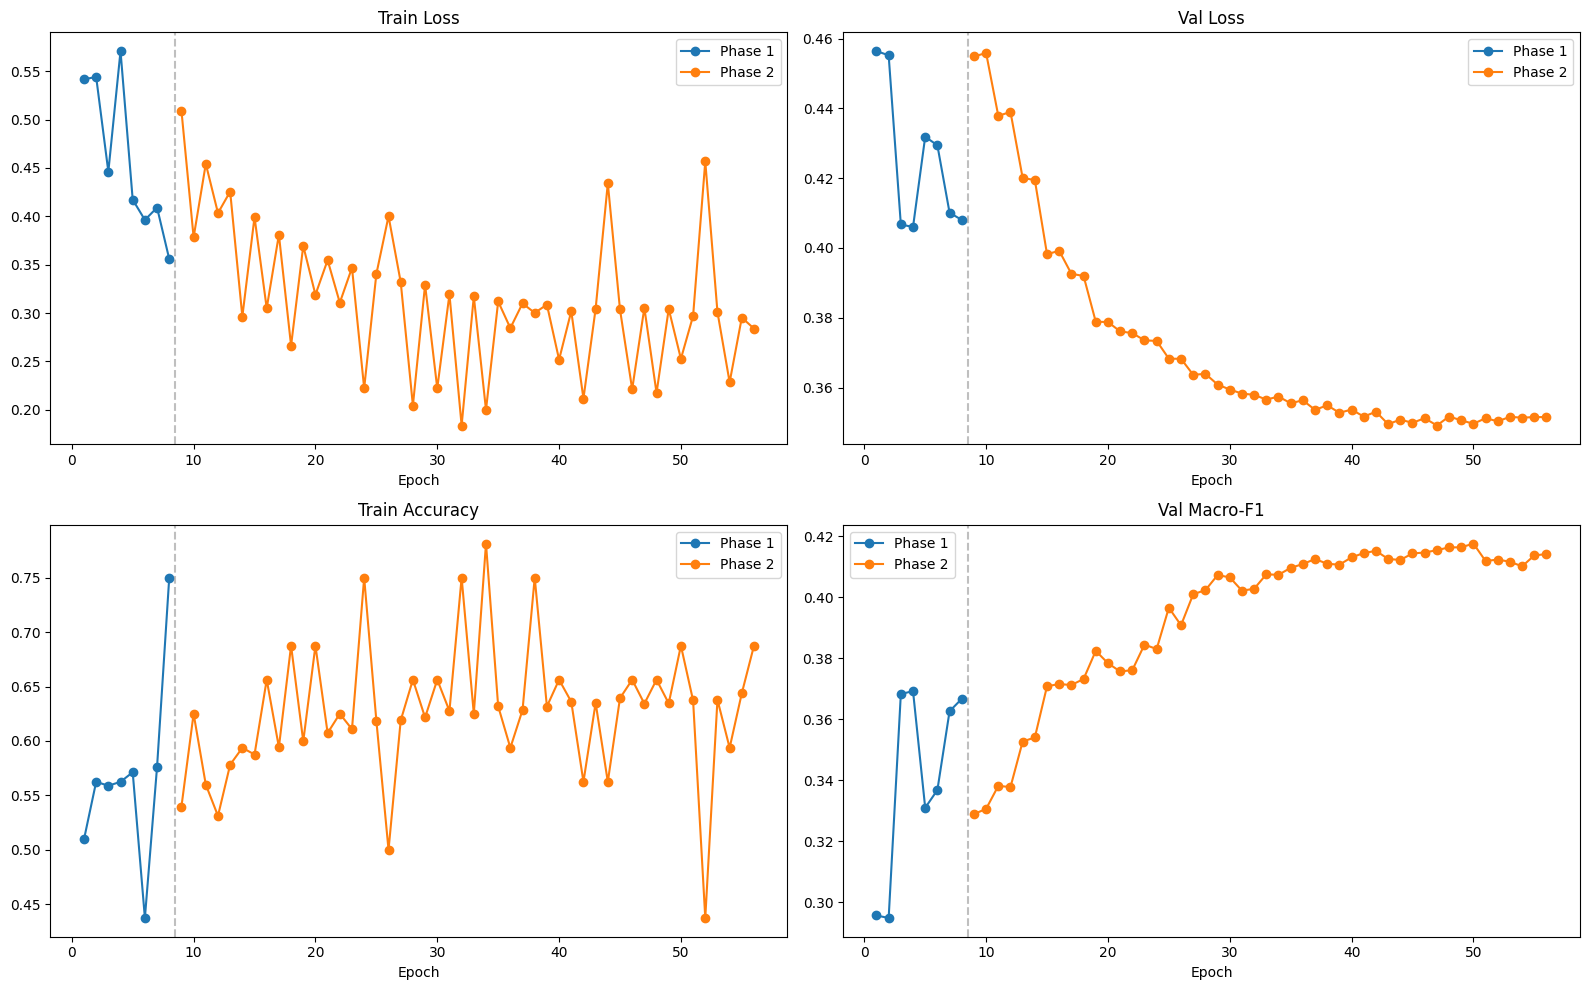

In [18]:
def plot_training_curves(history1, history2, metric, title):
    vals1 = history1.history.get(metric, [])
    vals2 = history2.history.get(metric, [])
    plt.plot(range(1, len(vals1) + 1), vals1, label='Phase 1', marker='o')
    plt.plot(range(len(vals1) + 1, len(vals1) + len(vals2) + 1), vals2, label='Phase 2', marker='o')
    plt.axvline(x=len(vals1) + 0.5, color='gray', linestyle='--', alpha=0.5)
    plt.title(title)
    plt.xlabel('Epoch')
    plt.legend()

plt.figure(figsize=(16, 10))

plt.subplot(2, 2, 1)
plot_training_curves(history_phase1, history_phase2, 'loss', 'Train Loss')

plt.subplot(2, 2, 2)
plot_training_curves(history_phase1, history_phase2, 'val_loss', 'Val Loss')

plt.subplot(2, 2, 3)
plot_training_curves(history_phase1, history_phase2, 'accuracy', 'Train Accuracy')

plt.subplot(2, 2, 4)
plot_training_curves(history_phase1, history_phase2, 'val_macro_f1', 'Val Macro-F1')

plt.tight_layout()
plt.show()

# Test

In [19]:
model.load_weights('/kaggle/working/best_hybrid_model_finetuned.h5')

FULL_LABELS = classes + ['UNK']
PRIORITY_CLASSES = ['MEL', 'BCC', 'AK', 'SCC']
PRIORITY_IDX = [classes.index(c) for c in PRIORITY_CLASSES]

PROCESSED_FINAL_TEST_DIR = '/kaggle/working/final_test_images_real/'
ROOT_FOLDER = '/kaggle/input/datasets/ruii2401/isic-2019'
TEST_CSV = os.path.join(ROOT_FOLDER, 'ISIC_2019_Test_GroundTruth.csv')
test_img_folder = os.path.join(ROOT_FOLDER, 'ISIC_2019_Test_Input', 'ISIC_2019_Test_Input')

In [20]:
# ============================================================
# BƯỚC 1: LOAD GROUND TRUTH TEST (TOÀN BỘ, KỂ CẢ UNK)
# ============================================================
print("🔄 Đang nạp Ground Truth test (toàn bộ, kể cả UNK)...")
df_test_full = pd.read_csv(TEST_CSV)
print(f"Tổng: {len(df_test_full)} ảnh | Biết lớp: {(df_test_full['UNK'] != 1.0).sum()} | UNK: {(df_test_full['UNK'] == 1.0).sum()}")

# ============================================================
# BƯỚC 2: XỬ LÝ DIP CHO TOÀN BỘ TEST
# ============================================================
if os.path.exists(PROCESSED_FINAL_TEST_DIR):
    shutil.rmtree(PROCESSED_FINAL_TEST_DIR)
os.makedirs(PROCESSED_FINAL_TEST_DIR, exist_ok=True)

print(f"🛠️ Đang xử lý DIP cho toàn bộ {len(df_test_full)} ảnh test...")
for _, row in tqdm(df_test_full.iterrows(), total=len(df_test_full)):
    img_id = row['image']
    input_path = os.path.join(test_img_folder, f"{img_id}.jpg")
    output_path = os.path.join(PROCESSED_FINAL_TEST_DIR, f"{img_id}.jpg")
    if os.path.exists(input_path):
        _, proc = dull_razor_and_enhance(input_path)
        if proc is not None:
            proc = cv2.resize(proc, (224, 224))
            cv2.imwrite(output_path, cv2.cvtColor(proc, cv2.COLOR_RGB2BGR))

🔄 Đang nạp Ground Truth test (toàn bộ, kể cả UNK)...
Tổng: 8238 ảnh | Biết lớp: 6191 | UNK: 2047
🛠️ Đang xử lý DIP cho toàn bộ 8238 ảnh test...


100%|██████████| 8238/8238 [17:14<00:00,  7.96it/s]


In [21]:
# ============================================================
# BƯỚC 3: PREDICT BATCH CHO TOÀN BỘ TEST
# ============================================================
BATCH_SIZE = 64
valid_rows = [row for _, row in df_test_full.iterrows()
              if os.path.exists(os.path.join(PROCESSED_FINAL_TEST_DIR, f"{row['image']}.jpg"))]
print(f"📦 Số ảnh hợp lệ để dự đoán: {len(valid_rows)} / {len(df_test_full)}")

all_probs = []
is_unk_true = []
true_class_idx = []

print("\n🧠 AI đang dự đoán (batch)...")
for i in tqdm(range(0, len(valid_rows), BATCH_SIZE)):
    batch_rows = valid_rows[i:i + BATCH_SIZE]
    batch_imgs = []
    for row in batch_rows:
        img_path = os.path.join(PROCESSED_FINAL_TEST_DIR, f"{row['image']}.jpg")
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        batch_imgs.append(img.astype(np.float32))

    batch_arr = preprocess_input(np.stack(batch_imgs, axis=0))
    preds = model.predict(batch_arr, verbose=0)

    for row, pred in zip(batch_rows, preds):
        all_probs.append(pred)
        if row['UNK'] == 1.0:
            is_unk_true.append(True)
            true_class_idx.append(-1)
        else:
            is_unk_true.append(False)
            true_class_idx.append(int(np.argmax(row[classes].values)))

all_probs = np.array(all_probs)
is_unk_true = np.array(is_unk_true)
true_class_idx = np.array(true_class_idx)
confidence = all_probs.max(axis=1)
pred_class_idx = all_probs.argmax(axis=1)

📦 Số ảnh hợp lệ để dự đoán: 8238 / 8238

🧠 AI đang dự đoán (batch)...


 99%|█████████▉| 128/129 [00:38<00:00,  3.42it/s]2026-08-17 11:08:39.281006: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-17 11:08:39.417529: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
100%|██████████| 129/129 [00:49<00:00,  2.58it/s]



📊 CLOSED-SET (chỉ 8 lớp, chưa áp threshold UNK): 6191 mẫu
  class  precision  recall     f1  support
0   MEL      0.576   0.604  0.589     1327
1    NV      0.798   0.729  0.762     2495
2   BCC      0.481   0.609  0.537      975
3    AK      0.319   0.251  0.281      374
4   BKL      0.334   0.339  0.337      660
5    DF      0.280   0.308  0.293       91
6  VASC      0.381   0.356  0.368      104
7   SCC      0.218   0.164  0.187      165

📊 Macro-F1 closed-set: 0.4193
🔴 Recall trung bình nhóm ưu tiên (MEL/BCC/AK/SCC): 0.407


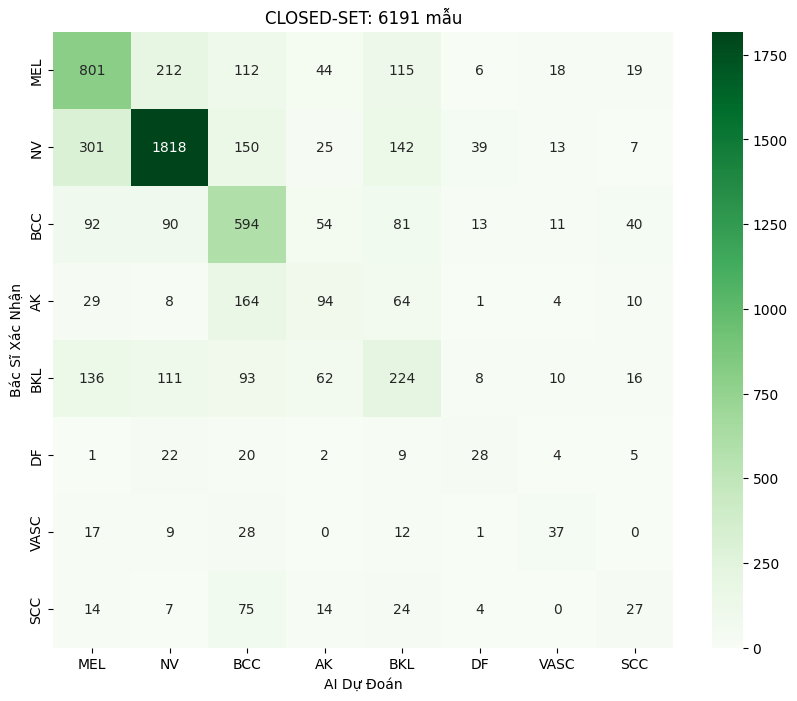

In [22]:
# ============================================================
# BƯỚC 4: CLOSED-SET METRICS (hiệu năng phân loại thuần túy, không liên quan threshold)
# ============================================================
known_mask = ~is_unk_true
y_true_closed = true_class_idx[known_mask]
y_pred_closed = pred_class_idx[known_mask]

print(f"\n📊 CLOSED-SET (chỉ 8 lớp, chưa áp threshold UNK): {known_mask.sum()} mẫu")

precision, recall, f1, support = precision_recall_fscore_support(
    y_true_closed, y_pred_closed, labels=range(8), zero_division=0
)
metrics_df = pd.DataFrame({'class': classes, 'precision': precision, 'recall': recall, 'f1': f1, 'support': support})
print(metrics_df.round(3))
print(f"\n📊 Macro-F1 closed-set: {f1.mean():.4f}")

malignant_recall = np.mean([recall[classes.index(c)] for c in PRIORITY_CLASSES])
print(f"🔴 Recall trung bình nhóm ưu tiên (MEL/BCC/AK/SCC): {malignant_recall:.3f}")

plt.figure(figsize=(10, 8))
cm_closed = confusion_matrix(y_true_closed, y_pred_closed)
sns.heatmap(cm_closed, annot=True, fmt='d', cmap='Greens', xticklabels=classes, yticklabels=classes)
plt.title(f'CLOSED-SET: {len(y_true_closed)} mẫu')
plt.xlabel('AI Dự Đoán')
plt.ylabel('Bác Sĩ Xác Nhận')
plt.show()

In [23]:
# ============================================================
# BƯỚC 5: CHIA CALIBRATION / EVAL CHO PHẦN THRESHOLD
# ============================================================
all_idx = np.arange(len(all_probs))
calib_idx, eval_idx = train_test_split(
    all_idx, test_size=0.5, random_state=42, stratify=is_unk_true
)

probs_calib = all_probs[calib_idx]
true_calib = true_class_idx[calib_idx]
unk_calib = is_unk_true[calib_idx]
confidence_calib = probs_calib.max(axis=1)
pred_calib_argmax = probs_calib.argmax(axis=1)
true_calib_full = np.where(unk_calib, 8, true_calib)

probs_eval = all_probs[eval_idx]
true_eval = true_class_idx[eval_idx]
unk_eval = is_unk_true[eval_idx]
confidence_eval = probs_eval.max(axis=1)
true_eval_full = np.where(unk_eval, 8, true_eval)

print(f"\n📊 Calibration: {len(calib_idx)} ảnh | Eval: {len(eval_idx)} ảnh")

fpr, tpr, thresholds = roc_curve(unk_calib.astype(int), 1 - confidence_calib)


📊 Calibration: 4119 ảnh | Eval: 4119 ảnh



📊 Bảng sweep (Calibration set):
    cost_ratio  threshold  macro_f1  priority_recall
0          1.0     0.4830    0.2915           0.1779
1          1.5     0.3528    0.3281           0.3009
2          2.0     0.2346    0.3075           0.3809
3          2.5     0.1700    0.3012           0.3906
4          3.0     0.1700    0.3012           0.3906
5          3.5     0.1700    0.3012           0.3906
6          4.0     0.1700    0.3012           0.3906
7          4.5     0.1700    0.3012           0.3906
8          5.0     0.1700    0.3012           0.3906
9          5.5     0.1700    0.3012           0.3906
10         6.0     0.1700    0.3012           0.3906
11         6.5     0.1700    0.3012           0.3906
12         7.0     0.1700    0.3012           0.3906
13         7.5     0.1700    0.3012           0.3906
14         8.0     0.1700    0.3012           0.3906
15         8.5     0.1700    0.3012           0.3906
16         9.0     0.1700    0.3012           0.3906
17         9.

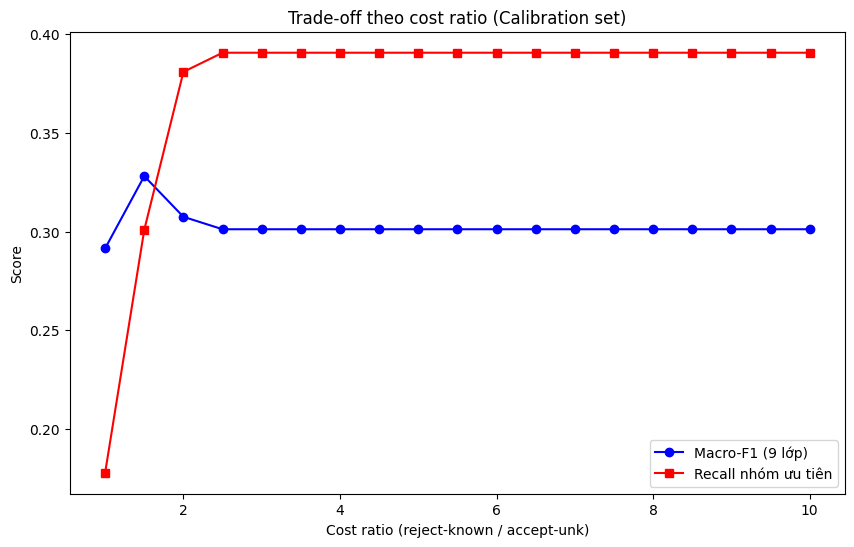

In [24]:
# ============================================================
# BƯỚC 6: SWEEP COST RATIO TRÊN CALIBRATION SET
# ============================================================
COST_RATIOS = np.arange(1.0, 10.5, 0.5)
results = []

for ratio in COST_RATIOS:
    total_cost = ratio * fpr + 1.0 * (1 - tpr)
    best_idx = np.argmin(total_cost)
    thr = 1 - thresholds[best_idx]

    final_pred_calib = np.where(confidence_calib < thr, 8, pred_calib_argmax)

    _, _, f1_c, _ = precision_recall_fscore_support(
        true_calib_full, final_pred_calib, labels=range(9), average='macro', zero_division=0
    )
    _, recall_per_class, _, _ = precision_recall_fscore_support(
        true_calib_full, final_pred_calib, labels=range(9), average=None, zero_division=0
    )
    priority_recall = np.mean([recall_per_class[i] for i in PRIORITY_IDX])

    results.append({
        'cost_ratio': ratio, 'threshold': round(thr, 4),
        'macro_f1': round(f1_c, 4), 'priority_recall': round(priority_recall, 4)
    })

results_df = pd.DataFrame(results)
print("\n📊 Bảng sweep (Calibration set):")
print(results_df)

fig, ax1 = plt.subplots(figsize=(10, 6))
ax1.plot(results_df['cost_ratio'], results_df['macro_f1'], marker='o', label='Macro-F1 (9 lớp)', color='blue')
ax1.plot(results_df['cost_ratio'], results_df['priority_recall'], marker='s', label='Recall nhóm ưu tiên', color='red')
ax1.set_xlabel('Cost ratio (reject-known / accept-unk)')
ax1.set_ylabel('Score')
ax1.legend()
ax1.set_title('Trade-off theo cost ratio (Calibration set)')
plt.show()


In [25]:
# ============================================================
# BƯỚC 7: CHỌN 3 CHÍNH SÁCH TỰ ĐỘNG
# ============================================================
idx_f1max = results_df['macro_f1'].idxmax()
idx_recallmax = results_df['priority_recall'].idxmax()

results_df['harmonic_combo'] = (
    2 * results_df['macro_f1'] * results_df['priority_recall']
    / (results_df['macro_f1'] + results_df['priority_recall'])
)
idx_balanced = results_df['harmonic_combo'].idxmax()

POLICIES = {
    'F1-max': results_df.loc[idx_f1max, 'cost_ratio'],
    'Recall-max': results_df.loc[idx_recallmax, 'cost_ratio'],
    'Can_bang': results_df.loc[idx_balanced, 'cost_ratio'],
}

print("\n📊 3 chính sách được chọn (dựa trên Calibration set):")
for name, ratio in POLICIES.items():
    row = results_df[results_df['cost_ratio'] == ratio].iloc[0]
    print(f"  {name}: cost_ratio={ratio} | threshold={row['threshold']} | "
          f"macro_f1={row['macro_f1']} | priority_recall={row['priority_recall']}")



📊 3 chính sách được chọn (dựa trên Calibration set):
  F1-max: cost_ratio=1.5 | threshold=0.35280001163482666 | macro_f1=0.3281 | priority_recall=0.3009
  Recall-max: cost_ratio=2.5 | threshold=0.17000000178813934 | macro_f1=0.3012 | priority_recall=0.3906
  Can_bang: cost_ratio=2.0 | threshold=0.2345999926328659 | macro_f1=0.3075 | priority_recall=0.3809


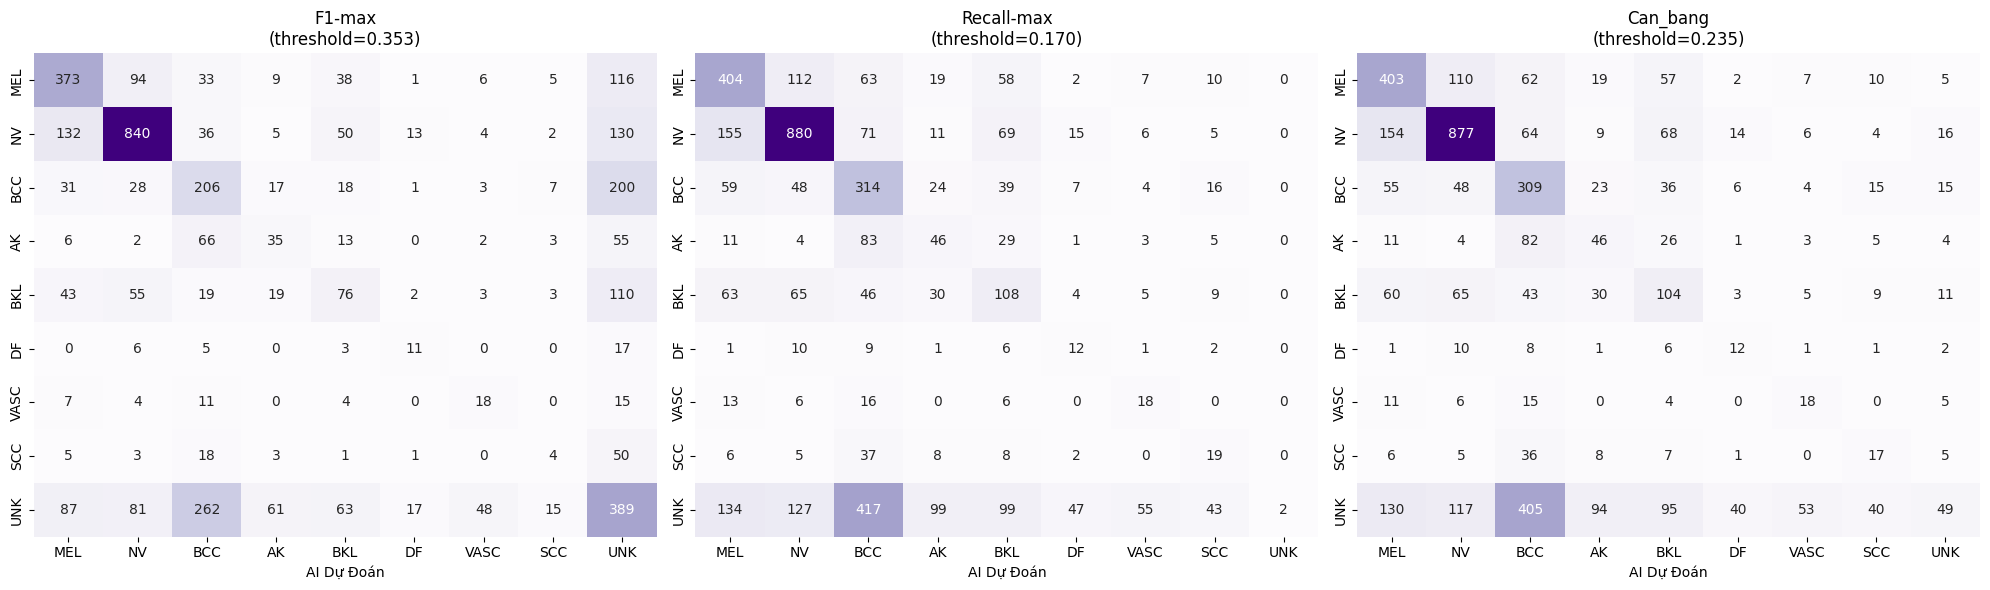


========================= F1-max (threshold=0.3528) =========================
              precision    recall  f1-score   support

         MEL       0.55      0.55      0.55       675
          NV       0.75      0.69      0.72      1212
         BCC       0.31      0.40      0.35       511
          AK       0.23      0.19      0.21       182
         BKL       0.29      0.23      0.26       330
          DF       0.24      0.26      0.25        42
        VASC       0.21      0.31      0.25        59
         SCC       0.10      0.05      0.06        85
         UNK       0.36      0.38      0.37      1023

    accuracy                           0.47      4119
   macro avg       0.34      0.34      0.34      4119
weighted avg       0.48      0.47      0.48      4119


========================= Recall-max (threshold=0.1700) =========================
              precision    recall  f1-score   support

         MEL       0.48      0.60      0.53       675
          NV       0.70 

In [26]:
# ============================================================
# BƯỚC 8: ÁP 3 CHÍNH SÁCH LÊN EVAL SET — CHỈ 1 LẦN DUY NHẤT
# ============================================================
policy_thresholds = {}
for name, ratio in POLICIES.items():
    total_cost = ratio * fpr + 1.0 * (1 - tpr)
    best_idx = np.argmin(total_cost)
    policy_thresholds[name] = 1 - thresholds[best_idx]

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
for ax, (name, thr) in zip(axes, policy_thresholds.items()):
    pred_eval = np.where(confidence_eval < thr, 8, probs_eval.argmax(axis=1))
    cm = confusion_matrix(true_eval_full, pred_eval, labels=range(9))

    sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', ax=ax,
                xticklabels=FULL_LABELS, yticklabels=FULL_LABELS, cbar=False)
    ax.set_title(f'{name}\n(threshold={thr:.3f})')
    ax.set_xlabel('AI Dự Đoán')
plt.tight_layout()
plt.show()

# ============================================================
# BƯỚC 9: BÁO CÁO CHI TIẾT TỪNG CHÍNH SÁCH (EVAL SET)
# ============================================================
for name, thr in policy_thresholds.items():
    pred_eval = np.where(confidence_eval < thr, 8, probs_eval.argmax(axis=1))
    print(f"\n{'='*25} {name} (threshold={thr:.4f}) {'='*25}")
    print(classification_report(true_eval_full, pred_eval, labels=range(9),
                                 target_names=FULL_LABELS, zero_division=0))